In [1]:
import warnings
import concurrent.futures
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import named_arrays as na

with warnings.catch_warnings():
    # the article's variables are evaluated on import, and a few of them divide by zero harmlessly
    warnings.simplefilter("ignore", RuntimeWarning)
    import ccd_diffusion

plt.rcParams["figure.dpi"] = 150

In [2]:
tracks = ccd_diffusion.tracks
fits = tracks.fits()
flat = [f for f in fits if f.flat]
tc_paper, sm_paper = tracks.paper_model()
thickness = ccd_diffusion.ccd().thickness_substrate
D = thickness.to_value(u.um)
zf = sm_paper.to_value(u.um)
pixel = tracks.width_pixel
axis_slice = tracks.axis_slice
axis_pixel = tracks.axis_pixel
h = tracks.half_width
offsets = na.arange(-h, h + 1, axis=axis_pixel)

chips = {"FUV1": "tab:orange", "FUV2": "tab:blue", "SJI": "black"}
datasets = {
    "2014b": "2014-03-12, SAA protons, roll 0",
    "2014": "2014-04-07, cosmic rays, roll 0",
    "2018": "2018-03-16, cosmic rays, roll 0",
    "2018may": "2018-05-04, SAA protons, roll -90",
    "sji": "2018-05-04 to 06, SJI, SAA protons, roll -90",
}

print(f"{len(fits)} tracks, {len(flat)} flat")
print(f"CCD model: D = {thickness:.2f}, z_f = {sm_paper:.2f}, t_c = z_f / D = {tc_paper:.3f}")

10819 tracks, 4502 flat
CCD model: D = 14.00 um, z_f = 5.34 um, t_c = z_f / D = 0.382


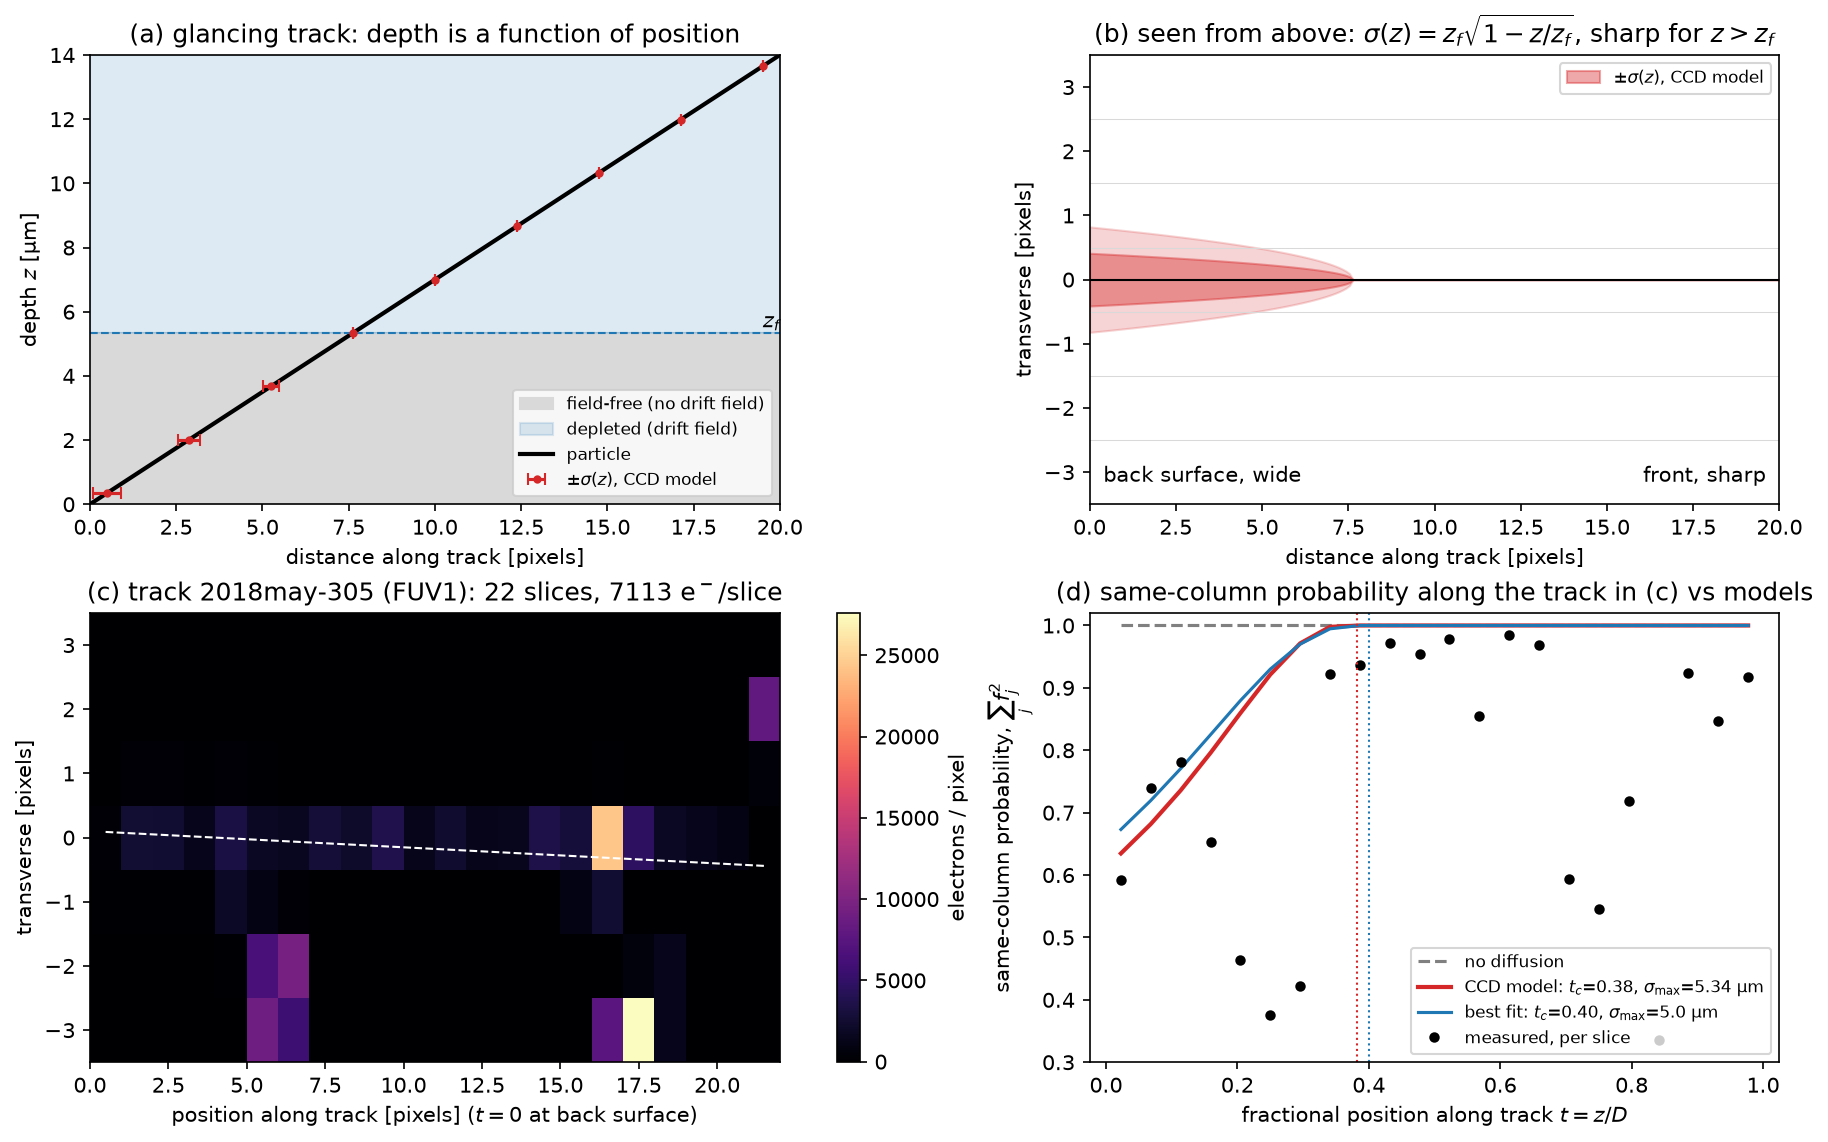

In [3]:
def unwrapped(fit):
    # the cutout re-centers every slice on the integer part of the centerline, so undo that
    # to draw the track in the coordinates of the parent image, relative to the first slice
    track = fit.track
    charge = track.charge
    position = fit.position
    if fit.orientation < 0:
        charge = charge[{axis_slice: slice(None, None, -1)}]
        position = position[{axis_slice: slice(None, None, -1)}]
    slope = track.slope if fit.orientation > 0 else -track.slope
    p = track.position.ndarray[::fit.orientation]
    shift = np.concatenate([[0], np.cumsum(np.round(slope - np.diff(p)))]).astype(int)
    shift = shift - shift.min()
    image = np.zeros((track.length, 2 * h + 1 + shift.max()))
    for i, k in enumerate(shift):
        image[i, k : k + 2 * h + 1] = charge[{axis_slice: i}].ndarray
    return image, position.ndarray + shift


example = next(f for f in fits if f.track.name == "2018may-305")
track = example.track
L = track.length

fig, ax = plt.subplots(2, 2, figsize=(12, 7.5), constrained_layout=True)
ax_a, ax_b, ax_c, ax_d = ax.flat

# (a) depth as a function of distance along a schematic glancing track, 20 pixels long
L_schematic = 20
x = na.linspace(0, L_schematic, axis="x", num=200)
z = D * x / L_schematic
ax_a.axhspan(0, zf, color="0.85", label="field-free (no drift field)")
ax_a.axhspan(zf, D, color="tab:blue", alpha=0.15, label="depleted (drift field)")
na.plt.plot(x, z, ax=ax_a, color="black", linewidth=2, label="particle")
sample = na.linspace(0.5, L_schematic - 0.5, axis="sample", num=9)
sigma = tracks.width(sample / L_schematic, tc_paper, sm_paper)
ax_a.errorbar(sample.ndarray, (D * sample / L_schematic).ndarray, xerr=sigma.ndarray, fmt="o", color="tab:red", markersize=3, capsize=3, linewidth=1.5, label=r"$\pm\sigma(z)$, CCD model")
ax_a.axhline(zf, linestyle="--", color="tab:blue", linewidth=1)
ax_a.text(L_schematic, zf, "$z_f$", ha="right", va="bottom")
ax_a.set_xlim(0, L_schematic)
ax_a.set_ylim(0, D)
ax_a.set_xlabel("distance along track [pixels]")
ax_a.set_ylabel("depth $z$ [µm]")
ax_a.set_title("(a) glancing track: depth is a function of position")
ax_a.legend(loc="lower right", fontsize=8)

# (b) the same track seen from above
sigma = tracks.width(x / L_schematic, tc_paper, sm_paper)
for k in range(-3, 4):
    ax_b.axhline(k + 0.5, color="0.85", linewidth=0.5)
ax_b.fill_between(x.ndarray, -2 * sigma.ndarray, 2 * sigma.ndarray, color="tab:red", alpha=0.2)
ax_b.fill_between(x.ndarray, -sigma.ndarray, sigma.ndarray, color="tab:red", alpha=0.4, label=r"$\pm\sigma(z)$, CCD model")
ax_b.axhline(0, color="black", linewidth=1)
ax_b.set_xlim(0, L_schematic)
ax_b.set_ylim(-3.5, 3.5)
ax_b.text(0.02, 0.05, "back surface, wide", transform=ax_b.transAxes)
ax_b.text(0.98, 0.05, "front, sharp", transform=ax_b.transAxes, ha="right")
ax_b.set_xlabel("distance along track [pixels]")
ax_b.set_ylabel("transverse [pixels]")
ax_b.set_title(r"(b) seen from above: $\sigma(z) = z_f \sqrt{1 - z / z_f}$, sharp for $z > z_f$")
ax_b.legend(loc="upper right", fontsize=8)

# (c) the example track
image, centerline = unwrapped(example)
mappable = ax_c.imshow(
    image.T,
    cmap="magma",
    origin="lower",
    extent=[0, L, -h - 0.5, image.shape[1] - h - 0.5],
    aspect="auto",
)
fig.colorbar(mappable, ax=ax_c, label="electrons / pixel")
ax_c.plot(np.arange(L) + 0.5, centerline, color="white", linestyle="--", linewidth=1)
ax_c.set_xlabel("position along track [pixels] ($t = 0$ at back surface)")
ax_c.set_ylabel("transverse [pixels]")
ax_c.set_title(f"(c) track {track.name} ({track.chip}): {L} slices, {track.signal.mean().ndarray:.0f} e$^-$/slice")

# (d) the same-pixel probability of every slice of the example track
t = example.depth.ndarray
order = np.argsort(t)
none = tracks.same_pixel_model(example, 0, 0 * u.um).ndarray
paper = tracks.same_pixel_model(example, tc_paper, sm_paper).ndarray
best = tracks.same_pixel_model(example, example.critical_depth, example.width_max).ndarray
measured = tracks.same_pixel(example).ndarray
ax_d.plot(t[order], none[order], color="gray", linestyle="--", label="no diffusion")
ax_d.plot(t[order], paper[order], color="tab:red", linewidth=2, label=rf"CCD model: $t_c$={tc_paper:.2f}, $\sigma_\mathrm{{max}}$={zf:.2f} µm")
ax_d.plot(t[order], best[order], color="tab:blue", label=rf"best fit: $t_c$={example.critical_depth:.2f}, $\sigma_\mathrm{{max}}$={example.width_max.to_value(u.um):.1f} µm")
ax_d.plot(t, measured, "o", color="black", markersize=4, label="measured, per slice")
ax_d.axvline(example.critical_depth, color="tab:blue", linestyle=":", linewidth=1)
ax_d.axvline(tc_paper, color="tab:red", linestyle=":", linewidth=1)
ax_d.set_ylim(0.3, 1.02)
ax_d.set_xlabel("fractional position along track $t = z / D$")
ax_d.set_ylabel(r"same-column probability, $\sum_j f_j^2$")
ax_d.set_title("(d) same-column probability along the track in (c) vs models")
ax_d.legend(fontsize=8, loc="lower right");

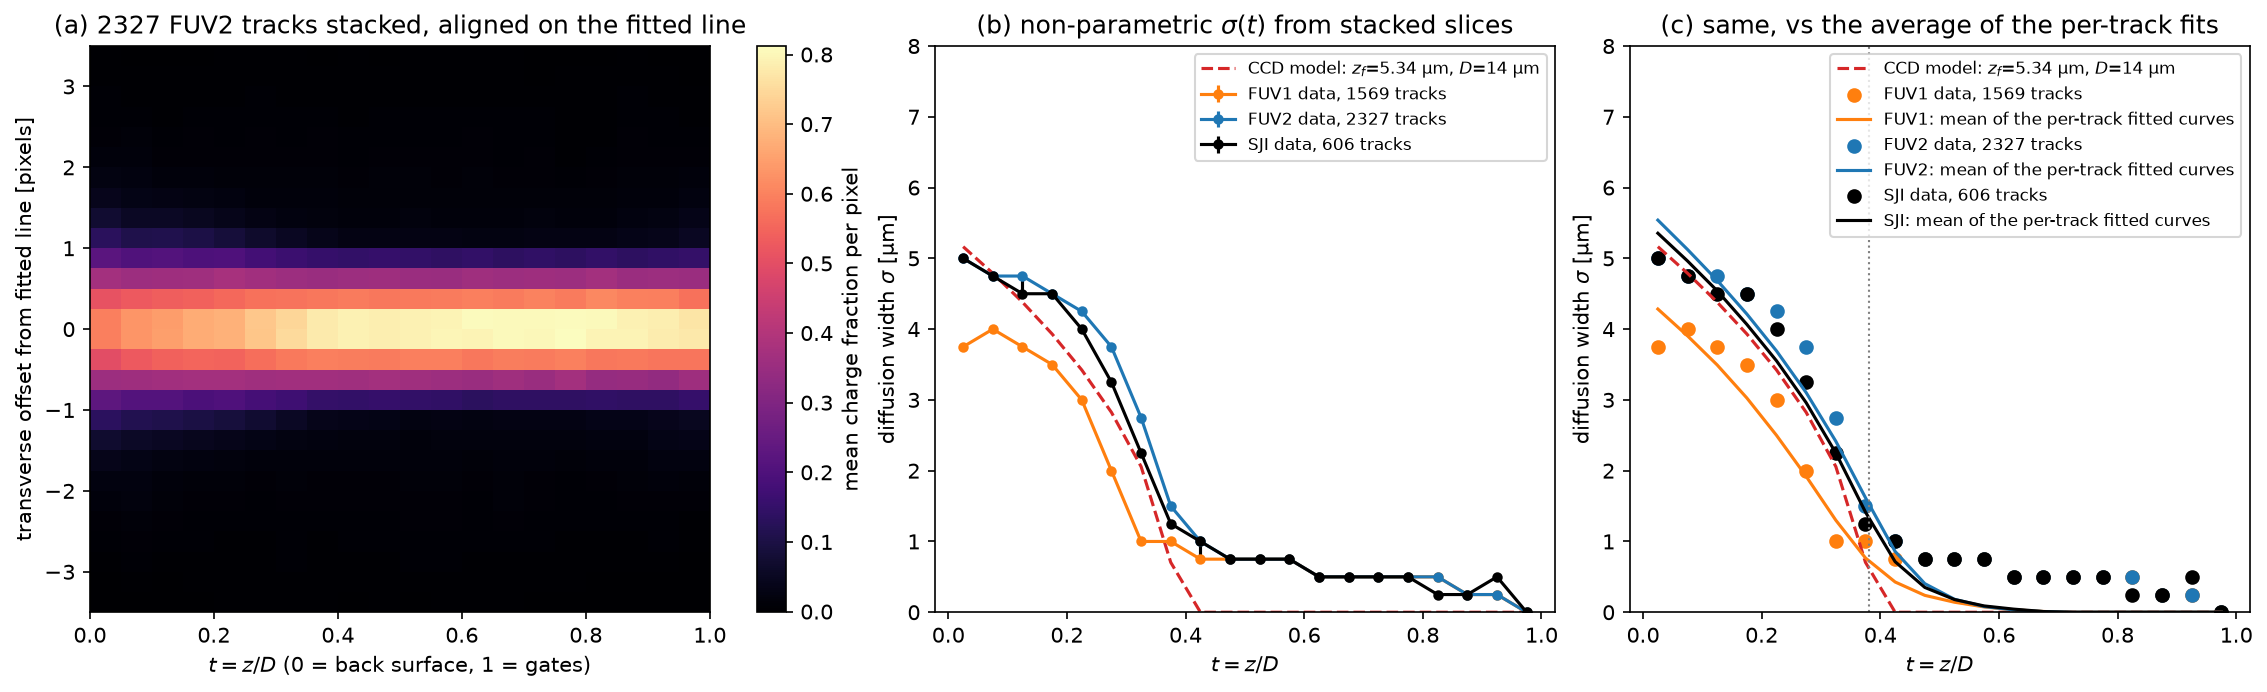

In [4]:
edges_depth = na.linspace(0, 1, axis="depth", num=21)
centers_depth = (edges_depth[dict(depth=slice(None, -1))] + edges_depth[dict(depth=slice(1, None))]) / 2
sigma = na.linspace(0, 10, axis="sigma", num=41) * u.um


def flat_tracks(chip):
    return [f for f in flat if f.track.chip == chip]


def stacked(chip, bins_offset=28):
    # the mean charge fraction per pixel as a function of depth and transverse offset from
    # the fitted centerline, with each pixel's charge spread uniformly over its own width
    t, x, w = [], [], []
    for f in flat_tracks(chip):
        distance = offsets - f.position
        fraction = f.track.fraction
        shape = na.shape_broadcasted(distance, fraction)
        t.append(na.broadcast_to(f.depth, shape).ndarray.ravel())
        x.append(na.broadcast_to(distance, shape).ndarray.ravel())
        w.append(na.broadcast_to(fraction, shape).ndarray.ravel())
    t, x, w = np.concatenate(t), np.concatenate(x), np.concatenate(w)
    edges_offset = np.linspace(-h - 0.5, h + 0.5, bins_offset + 1)
    lower = np.maximum(x[:, np.newaxis] - 0.5, edges_offset[np.newaxis, :-1])
    upper = np.minimum(x[:, np.newaxis] + 0.5, edges_offset[np.newaxis, 1:])
    overlap = np.clip(upper - lower, 0, None) / np.diff(edges_offset)
    index = np.clip(np.digitize(t, edges_depth.ndarray) - 1, 0, edges_depth.size - 2)
    total = np.zeros((edges_depth.size - 1, bins_offset))
    np.add.at(total, index, w[:, np.newaxis] * overlap)
    num = np.histogram(np.concatenate([f.depth.ndarray for f in flat_tracks(chip)]), bins=edges_depth.ndarray)[0]
    return total / num[:, np.newaxis], edges_offset


def nonparametric(chip):
    # the summed misfit of every slice in each depth bin as a function of a single width
    w = (sigma / pixel).to(u.dimensionless_unscaled).value
    nll = np.zeros((edges_depth.size - 1, sigma.size))
    for f in flat_tracks(chip):
        q = tracks.fractions(f.position, w, f.track.slope)
        r = (f.track.fraction - q) / f.track.error
        v = np.log1p(np.square(r) / 2).sum(axis_pixel)
        index = np.clip(np.digitize(f.depth.ndarray, edges_depth.ndarray) - 1, 0, nll.shape[0] - 1)
        np.add.at(nll, index, v.transpose((axis_slice, "sigma")).ndarray)
    best = sigma.ndarray[np.argmin(nll, axis=1)]
    ok = nll < nll.min(axis=1, keepdims=True) + 2
    lower = np.array([sigma.ndarray[row].min().value for row in ok]) * u.um
    upper = np.array([sigma.ndarray[row].max().value for row in ok]) * u.um
    return best, lower, upper


fig, ax = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
ax_a, ax_b, ax_c = ax

image, edges_offset = stacked("FUV2")
mappable = ax_a.imshow(image.T, origin="lower", cmap="magma", aspect="auto", extent=[0, 1, edges_offset[0], edges_offset[-1]])
fig.colorbar(mappable, ax=ax_a, label="mean charge fraction per pixel")
ax_a.set_xlabel("$t = z / D$ (0 = back surface, 1 = gates)")
ax_a.set_ylabel("transverse offset from fitted line [pixels]")
ax_a.set_title(f"(a) {len(flat_tracks('FUV2'))} FUV2 tracks stacked, aligned on the fitted line")

model = tracks.width(centers_depth, tc_paper, sm_paper) * pixel
for a in (ax_b, ax_c):
    na.plt.plot(centers_depth, model, ax=a, color="tab:red", linestyle="--", label=f"CCD model: $z_f$={zf:.2f} µm, $D$={D:.0f} µm")
for chip, color in chips.items():
    best, lower, upper = nonparametric(chip)
    yerr = np.stack([(best - lower).value, (upper - best).value])
    label = f"{chip} data, {len(flat_tracks(chip))} tracks"
    ax_b.errorbar(centers_depth.ndarray, best.value, yerr, fmt="o-", color=color, markersize=4, label=label)
    ax_c.scatter(centers_depth.ndarray, best.value, color=color, label=label)
    curves = na.stack([tracks.width(centers_depth, f.critical_depth, f.width_max) for f in flat_tracks(chip)], axis="track")
    na.plt.plot(centers_depth, curves.mean("track") * pixel, ax=ax_c, color=color, label=f"{chip}: mean of the per-track fitted curves")
ax_c.axvline(tc_paper, color="gray", linestyle=":", linewidth=1)
for a, title in ((ax_b, r"(b) non-parametric $\sigma(t)$ from stacked slices"), (ax_c, "(c) same, vs the average of the per-track fits")):
    a.set_xlabel("$t = z / D$")
    a.set_ylabel(r"diffusion width $\sigma$ [µm]")
    a.set_ylim(0, 8)
    a.set_title(title)
    a.legend(fontsize=8)

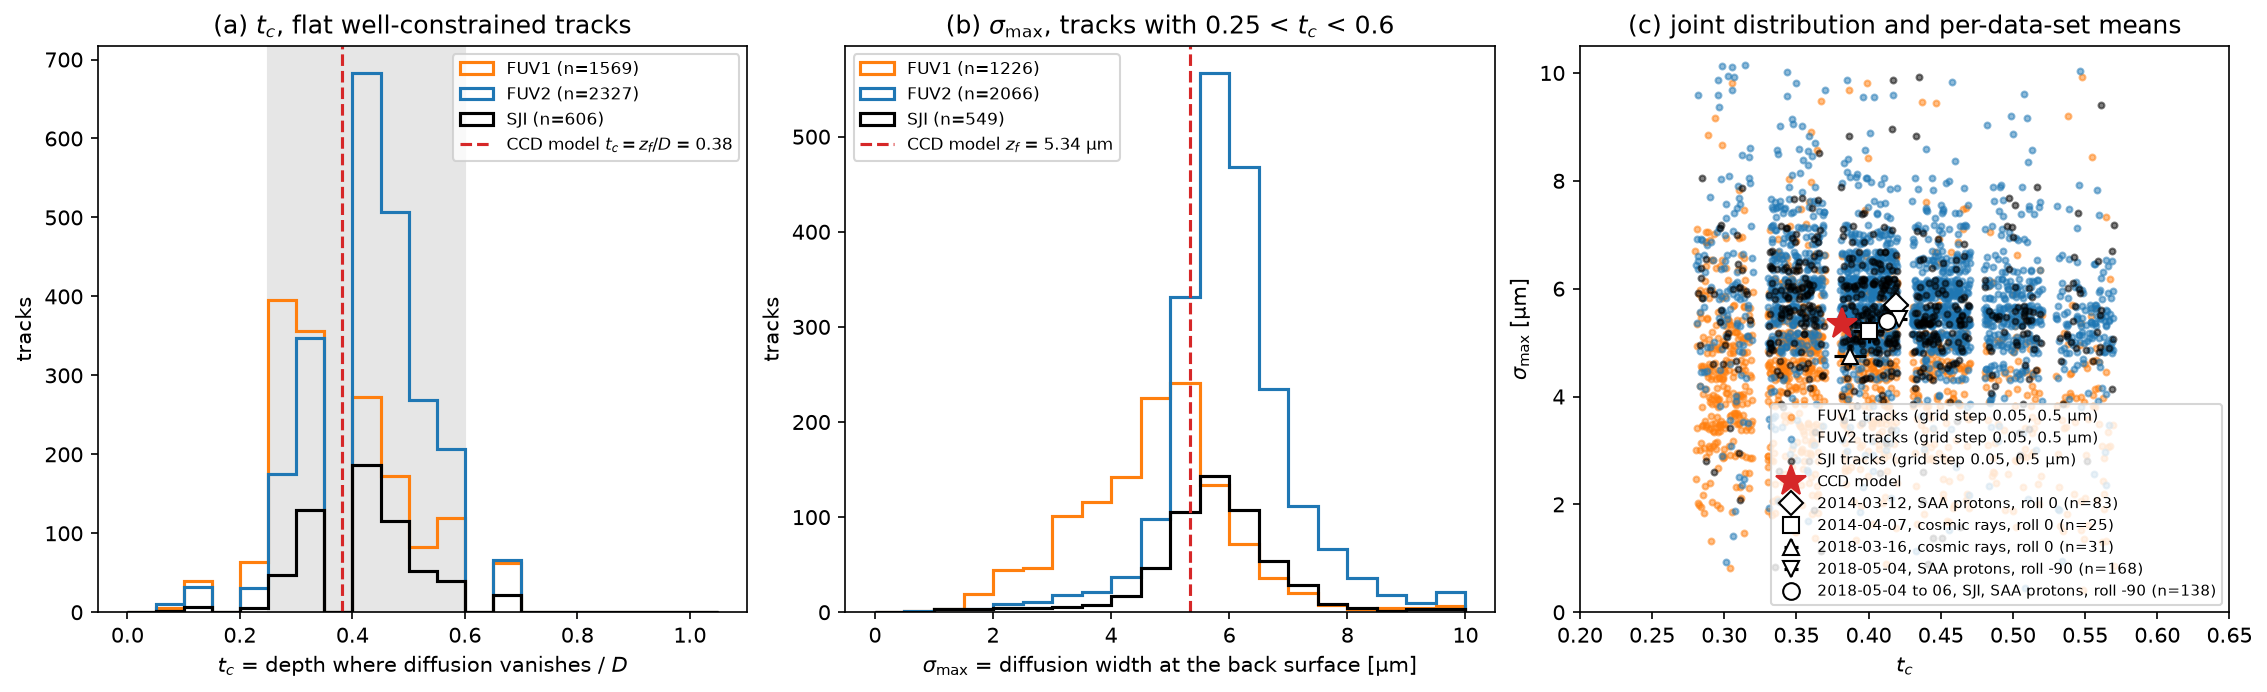

In [5]:
core = [f for f in flat if 0.25 < f.critical_depth < 0.6]
rng = np.random.default_rng(0)

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
ax_a, ax_b, ax_c = ax

ax_a.axvspan(0.25, 0.6, color="0.9")
for chip, color in chips.items():
    tc = [f.critical_depth for f in flat_tracks(chip)]
    ax_a.hist(tc, bins=np.arange(0, 1.06, 0.05), histtype="step", linewidth=1.5, color=color, label=f"{chip} (n={len(tc)})")
ax_a.axvline(tc_paper, color="tab:red", linestyle="--", label=f"CCD model $t_c = z_f / D$ = {tc_paper:.2f}")
ax_a.set_xlabel("$t_c$ = depth where diffusion vanishes / $D$")
ax_a.set_ylabel("tracks")
ax_a.set_title("(a) $t_c$, flat well-constrained tracks")
ax_a.legend(fontsize=8)

for chip, color in chips.items():
    sm = [f.width_max.to_value(u.um) for f in core if f.track.chip == chip]
    ax_b.hist(sm, bins=np.arange(0, 10.1, 0.5), histtype="step", linewidth=1.5, color=color, label=f"{chip} (n={len(sm)})")
ax_b.axvline(zf, color="tab:red", linestyle="--", label=f"CCD model $z_f$ = {zf:.2f} µm")
ax_b.set_xlabel(r"$\sigma_\mathrm{max}$ = diffusion width at the back surface [µm]")
ax_b.set_ylabel("tracks")
ax_b.set_title(r"(b) $\sigma_\mathrm{max}$, tracks with 0.25 < $t_c$ < 0.6")
ax_b.legend(fontsize=8)

for chip, color in chips.items():
    subset = [f for f in core if f.track.chip == chip]
    tc = np.array([f.critical_depth for f in subset]) + rng.uniform(-0.02, 0.02, len(subset))
    sm = np.array([f.width_max.to_value(u.um) for f in subset]) + rng.uniform(-0.2, 0.2, len(subset))
    ax_c.scatter(tc, sm, s=8, color=color, alpha=0.5, label=f"{chip} tracks (grid step 0.05, 0.5 µm)")
ax_c.plot(tc_paper, zf, "*", color="tab:red", markersize=15, label="CCD model")
markers = ["D", "s", "^", "v", "o"]
for (dataset, label), marker in zip(datasets.items(), markers):
    subset = [f for f in core if f.track.dataset == dataset]
    tc = np.array([f.critical_depth for f in subset])
    sm = np.array([f.width_max.to_value(u.um) for f in subset])
    ax_c.errorbar(tc.mean(), sm.mean(), xerr=tc.std() / np.sqrt(len(tc)), yerr=sm.std() / np.sqrt(len(sm)), fmt=marker, color="black", markerfacecolor="white", markersize=8, label=f"{label} (n={len(subset)})")
ax_c.set_xlim(0.2, 0.65)
ax_c.set_ylim(0, 10.5)
ax_c.set_xlabel("$t_c$")
ax_c.set_ylabel(r"$\sigma_\mathrm{max}$ [µm]")
ax_c.set_title("(c) joint distribution and per-data-set means")
ax_c.legend(fontsize=7, loc="lower right");

FUV1: 3976 tracks, 1569 flat, back surface p = 0.647 ± 0.003, P = p² = 0.419 ± 0.004, model P = 0.335


FUV2: 5281 tracks, 2327 flat, back surface p = 0.577 ± 0.002, P = p² = 0.333 ± 0.003, model P = 0.340


SJI: 1562 tracks, 606 flat, back surface p = 0.592 ± 0.005, P = p² = 0.351 ± 0.006, model P = 0.335


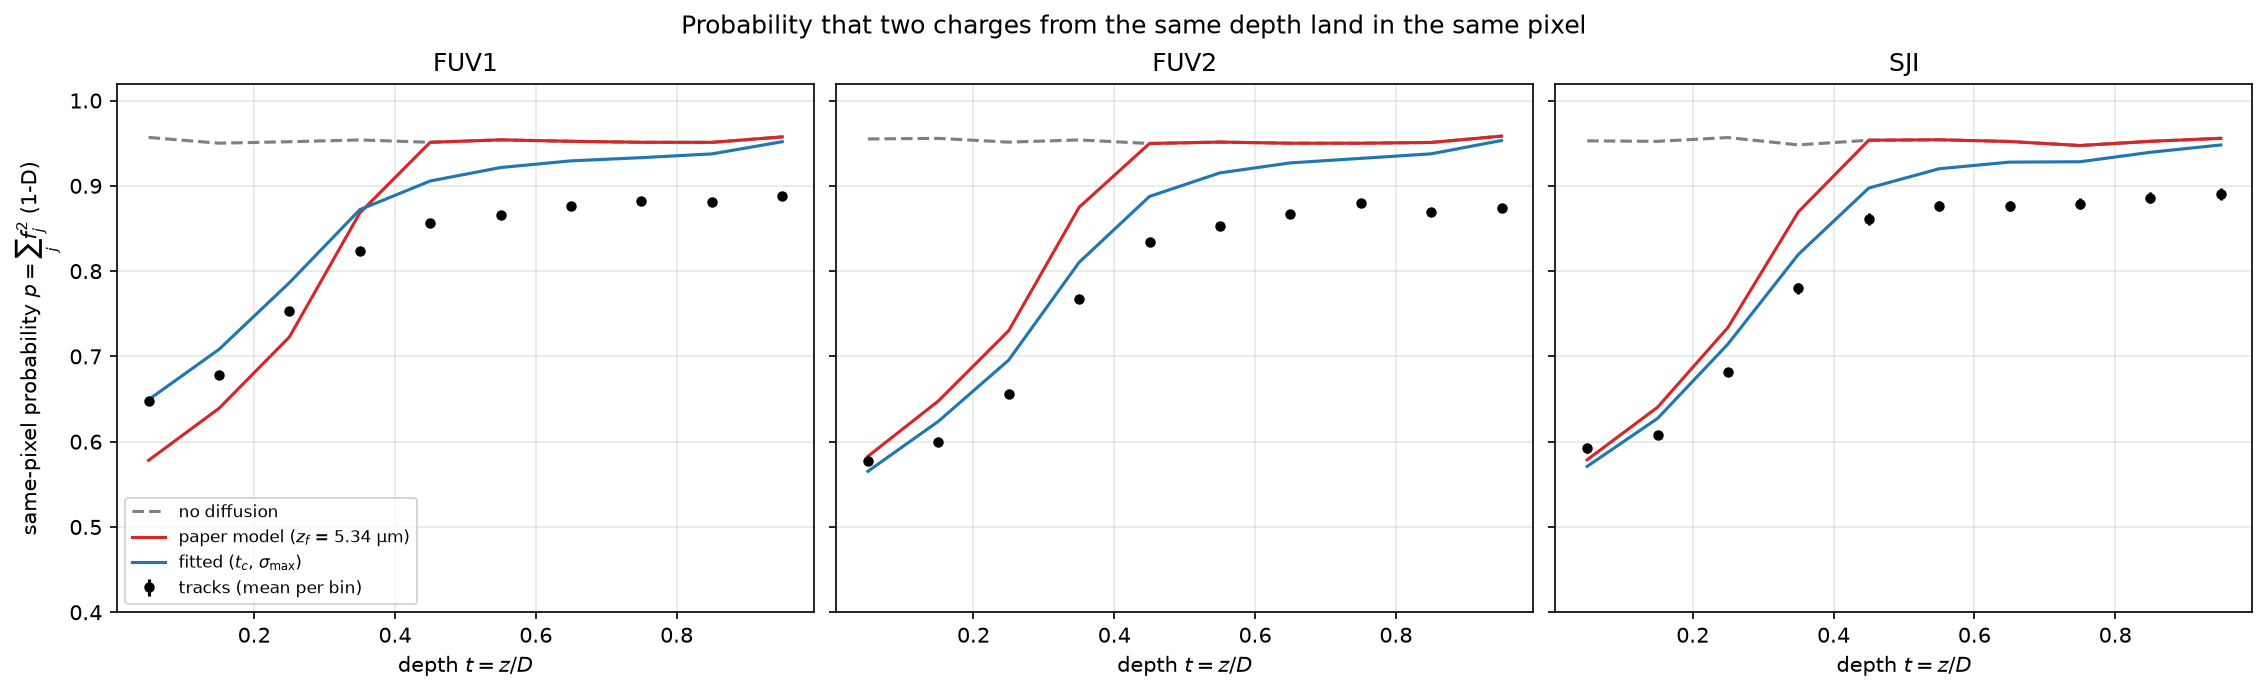

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True, constrained_layout=True)
for a, chip in zip(ax, chips):
    p = tracks.profile(chip)
    na.plt.plot(p.depth, p.none, ax=a, color="gray", linestyle="--", label="no diffusion")
    na.plt.plot(p.depth, p.paper, ax=a, color="tab:red", label=rf"paper model ($z_f$ = {zf:.2f} µm)")
    na.plt.plot(p.depth, p.fitted, ax=a, color="tab:blue", label=r"fitted ($t_c$, $\sigma_\mathrm{max}$)")
    a.errorbar(p.depth.ndarray, p.measured.ndarray, p.error.ndarray, fmt="o", color="black", markersize=4, label="tracks (mean per bin)")
    a.set_xlabel("depth $t = z / D$")
    a.set_title(chip)
    a.grid(alpha=0.3)
ax[0].set_ylabel(r"same-pixel probability $p = \sum_j f_j^2$ (1-D)")
ax[0].set_ylim(0.4, 1.02)
ax[0].legend(fontsize=8)
fig.suptitle("Probability that two charges from the same depth land in the same pixel")

for chip in chips:
    s = tracks.summary(chip)
    print(
        f"{chip}: {s.num_tracks} tracks, {s.num_flat} flat, "
        f"back surface p = {s.same_pixel_1d:.3f} ± {s.same_pixel_1d_error:.3f}, "
        f"P = p² = {s.same_pixel:.3f} ± {s.same_pixel_error:.3f}, "
        f"model P = {s.same_pixel_paper:.3f}"
    )

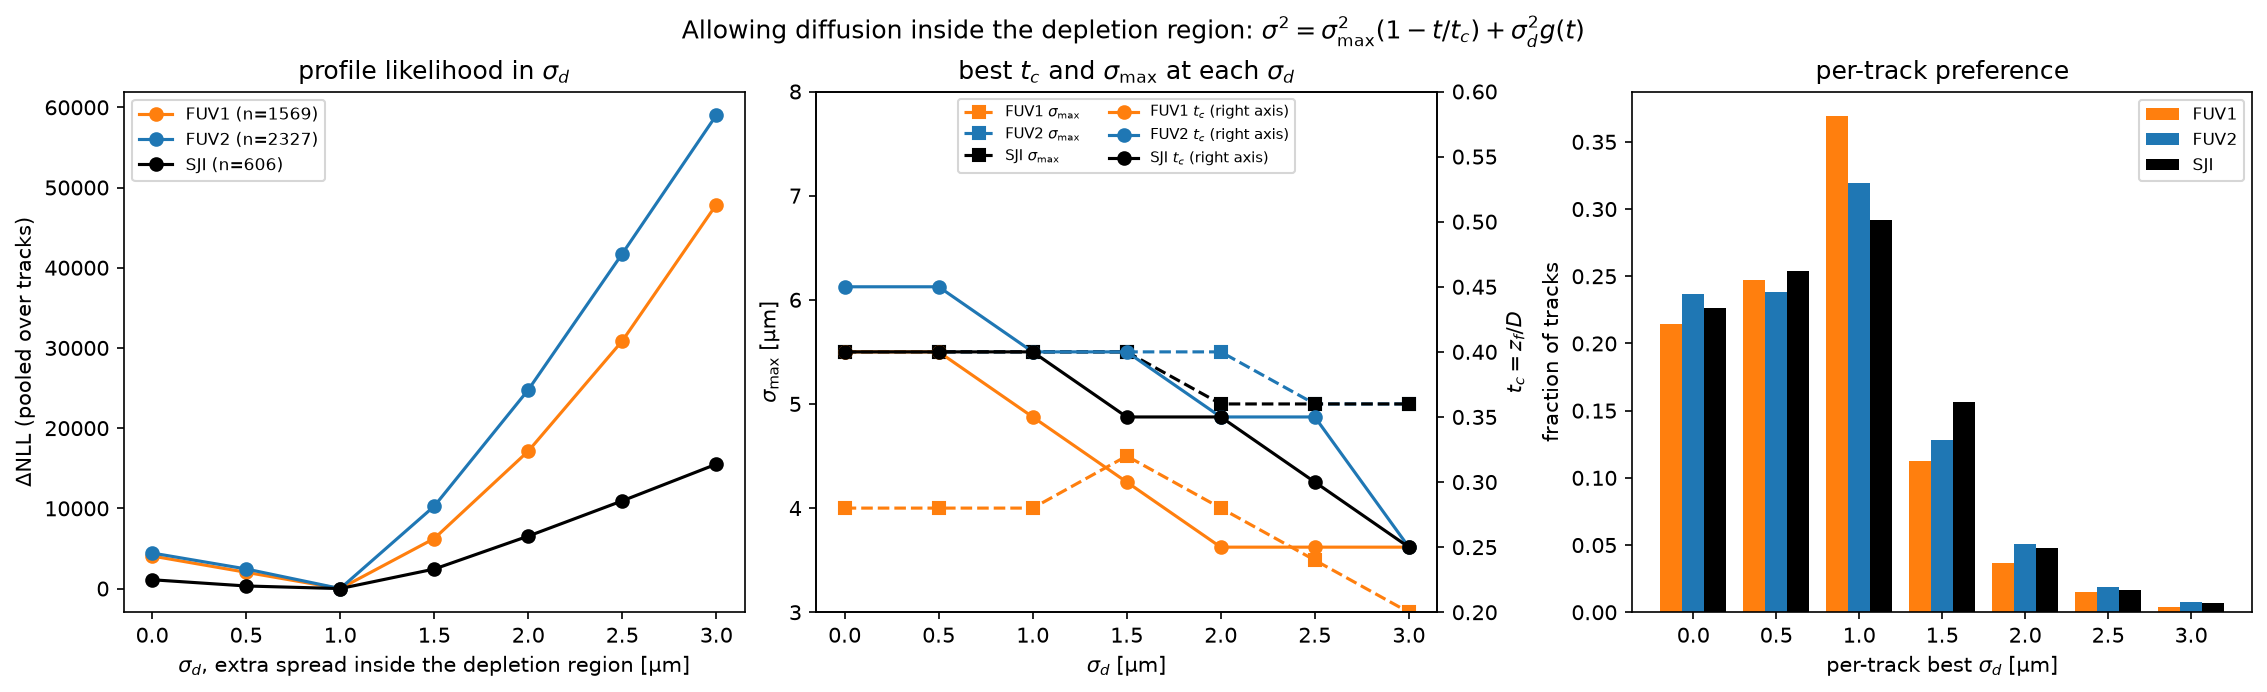

In [7]:
axis_depleted = "width_depleted"
grid_tc = na.linspace(0.25, 0.6, axis=tracks.axis_critical_depth, num=8)
grid_sm = na.linspace(2, 8, axis=tracks.axis_width_max, num=13) * u.um
grid_sd = na.linspace(0, 3, axis=axis_depleted, num=7) * u.um


def width_depleted(depth, critical_depth, width_max, width_depleted):
    # the field-free model plus an extra spread that decays linearly across the depletion region
    field_free = np.square(width_max) * np.maximum(1 - depth / critical_depth, 0)
    g = np.minimum((1 - depth) / (1 - critical_depth), 1)
    result = np.sqrt(field_free + np.square(width_depleted) * g)
    return (result / pixel).to(u.dimensionless_unscaled).value


def misfit_depleted(f):
    # the misfit of one track on the three-parameter grid, minimized over the nuisance grid of the package
    position = f.track.position + tracks.offset + tracks.tilt * f.track.index
    w = width_depleted(f.depth, grid_tc, grid_sm, grid_sd)
    return tracks.loss(f.track, position, w).min((tracks.axis_offset, tracks.axis_tilt))


with concurrent.futures.ThreadPoolExecutor() as pool:
    misfits = list(pool.map(misfit_depleted, flat))

pooled = {chip: 0 for chip in chips}
preferred = {chip: [] for chip in chips}
for f, v in zip(flat, misfits):
    pooled[f.track.chip] = pooled[f.track.chip] + v
    preferred[f.track.chip].append(grid_sd[np.argmin(v, axis=v.axes)].ndarray.to_value(u.um))

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
ax_a, ax_b, ax_c = ax
ax_tc = ax_b.twinx()
for chip, color in chips.items():
    v = pooled[chip]
    profile = v.min((tracks.axis_critical_depth, tracks.axis_width_max))
    na.plt.plot(grid_sd, profile - profile.min(), ax=ax_a, marker="o", color=color, label=f"{chip} (n={len(preferred[chip])})")
    index = np.argmin(v, axis=(tracks.axis_critical_depth, tracks.axis_width_max))
    na.plt.plot(grid_sd, grid_sm[index], ax=ax_b, marker="s", linestyle="--", color=color, label=rf"{chip} $\sigma_\mathrm{{max}}$")
    na.plt.plot(grid_sd, grid_tc[index], ax=ax_tc, marker="o", color=color, label=f"{chip} $t_c$ (right axis)")
ax_c.hist(list(preferred.values()), bins=np.arange(-0.25, 3.3, 0.5), color=list(chips.values()), label=list(chips), density=False, weights=[np.ones(len(p)) / len(p) for p in preferred.values()])
ax_a.set_xlabel(r"$\sigma_d$, extra spread inside the depletion region [µm]")
ax_a.set_ylabel(r"$\Delta$NLL (pooled over tracks)")
ax_a.set_title(r"profile likelihood in $\sigma_d$")
ax_a.legend(fontsize=8)
ax_b.set_xlabel(r"$\sigma_d$ [µm]")
ax_b.set_ylabel(r"$\sigma_\mathrm{max}$ [µm]")
ax_b.set_ylim(3, 8)
ax_tc.set_ylabel("$t_c = z_f / D$")
ax_tc.set_ylim(0.2, 0.6)
ax_b.set_title(r"best $t_c$ and $\sigma_\mathrm{max}$ at each $\sigma_d$")
handles, labels = ax_b.get_legend_handles_labels()
handles_tc, labels_tc = ax_tc.get_legend_handles_labels()
ax_tc.legend(handles + handles_tc, labels + labels_tc, fontsize=7, loc="upper center", ncol=2)
ax_c.set_xlabel(r"per-track best $\sigma_d$ [µm]")
ax_c.set_ylabel("fraction of tracks")
ax_c.set_title("per-track preference")
ax_c.legend(fontsize=8)
fig.suptitle(r"Allowing diffusion inside the depletion region: $\sigma^2 = \sigma_\mathrm{max}^2 (1 - t / t_c) + \sigma_d^2 g(t)$");

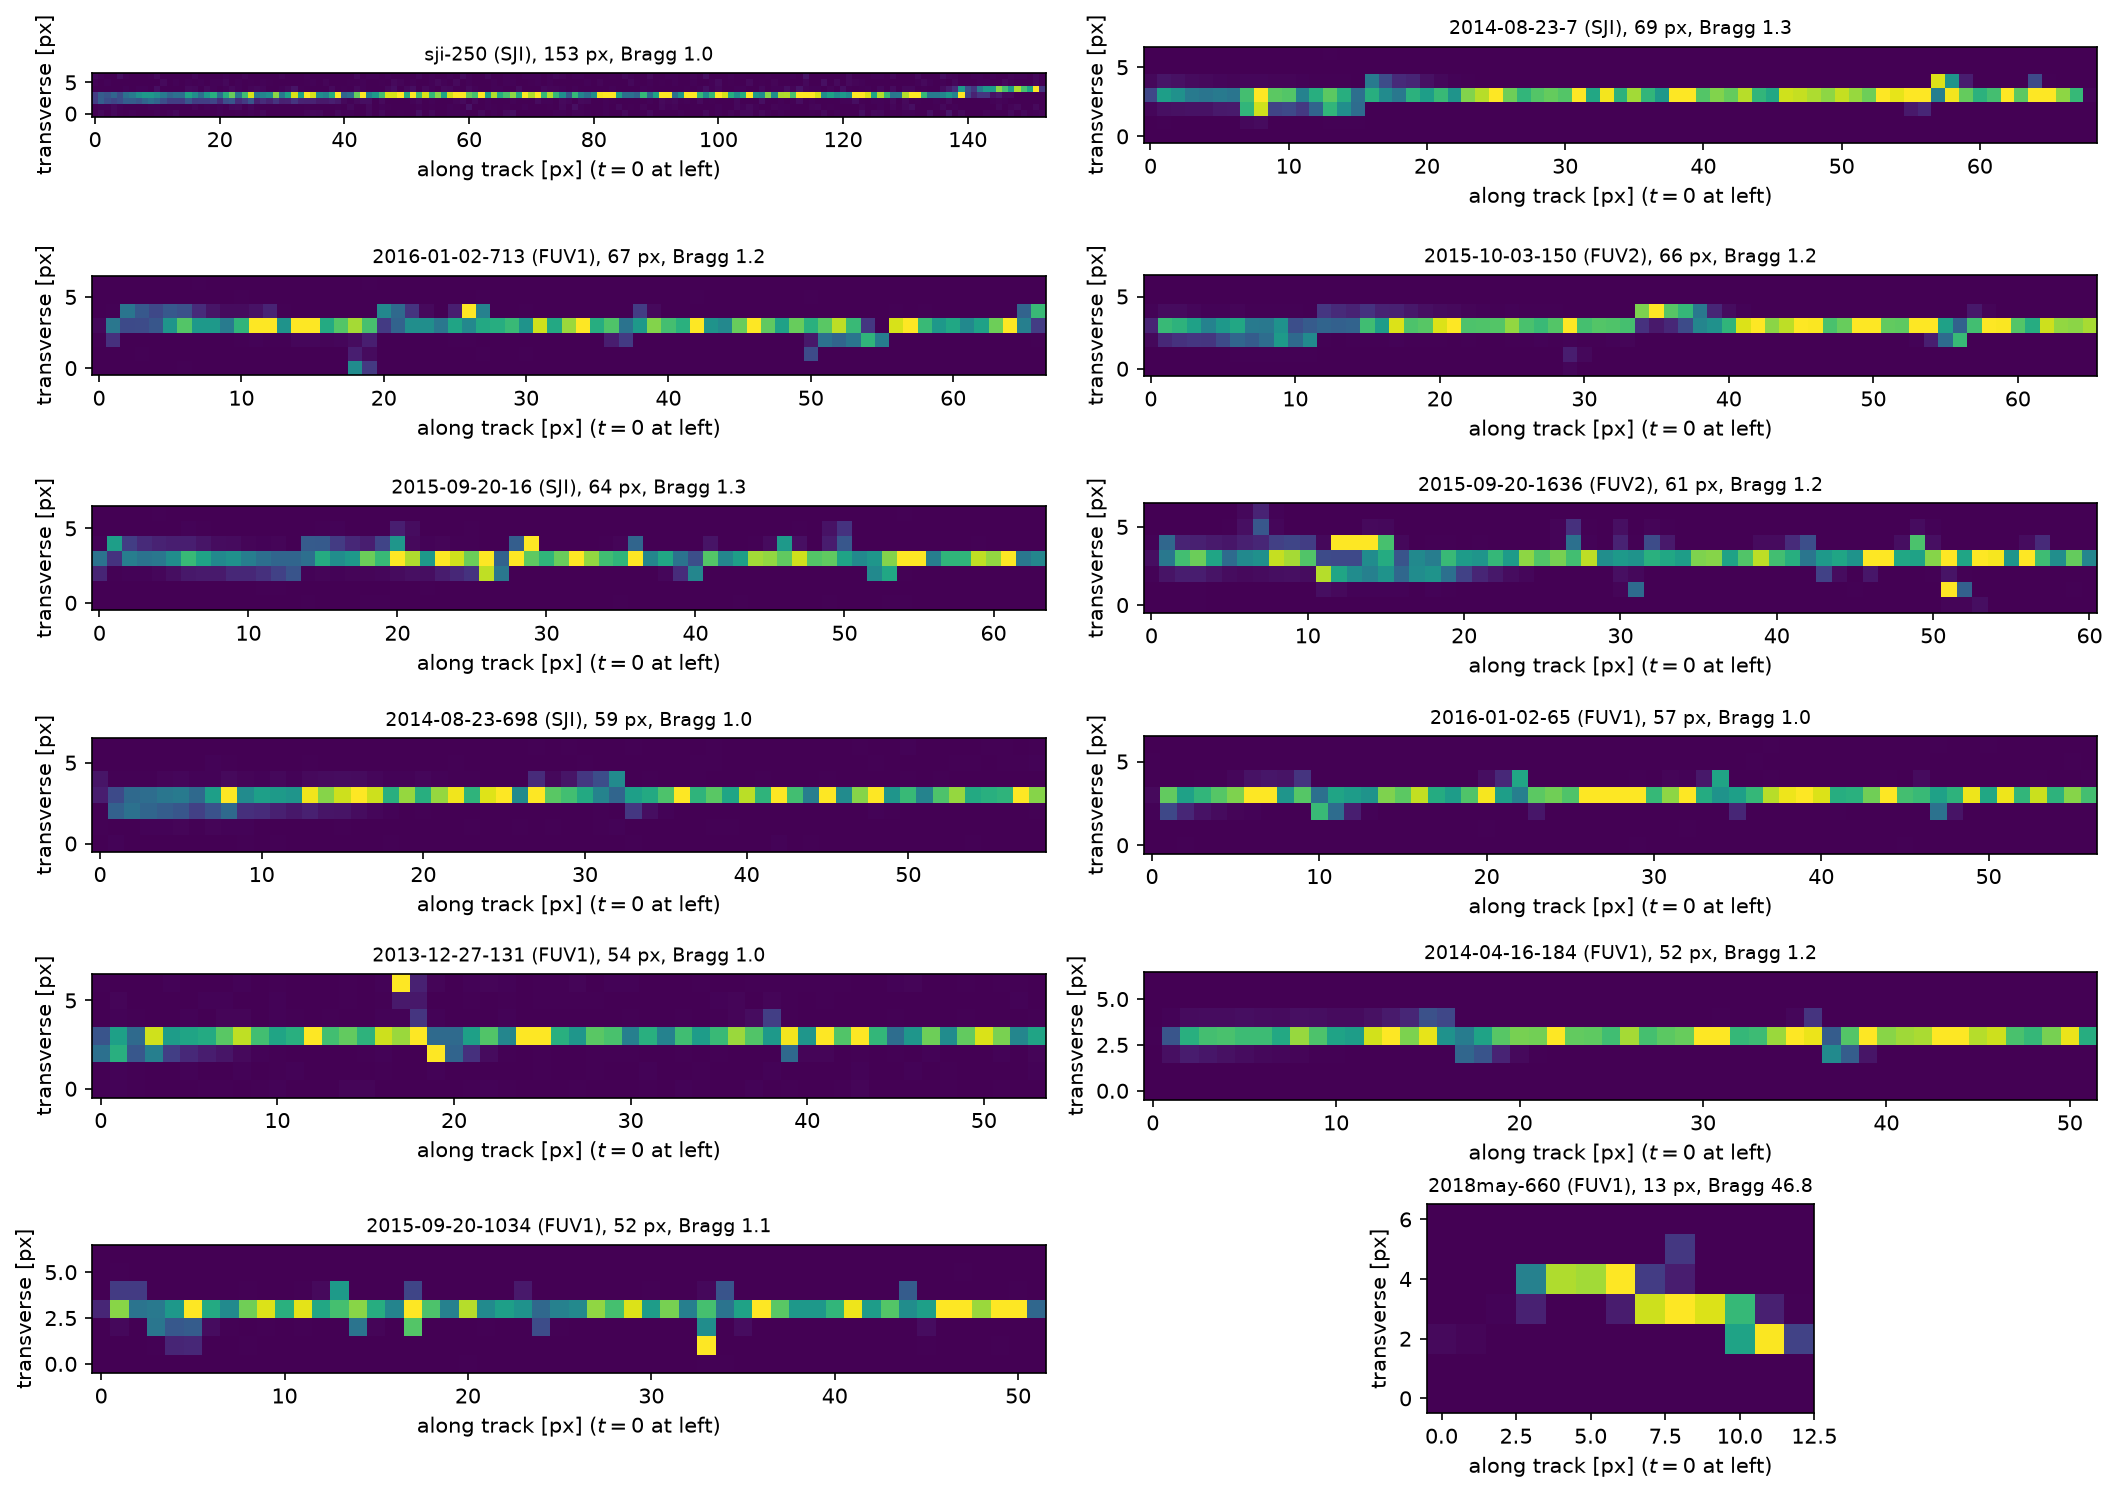

In [8]:
longest = sorted(flat, key=lambda f: -f.track.length)[:11]
stopping = max(fits, key=lambda f: f.bragg)

fig, ax = plt.subplots(6, 2, figsize=(14, 10), constrained_layout=True)
for a, f in zip(ax.flat, longest + [stopping]):
    charge = f.track.charge
    if f.orientation < 0:
        charge = charge[{axis_slice: slice(None, None, -1)}]
    image = charge.transpose((axis_pixel, axis_slice)).ndarray
    a.imshow(image, cmap="viridis", origin="lower", aspect="equal", interpolation="none", vmin=0, vmax=np.percentile(image, 98))
    a.set_title(f"{f.track.name} ({f.track.chip}), {f.track.length} px, Bragg {f.bragg:.1f}", fontsize=9)
    a.set_xlabel("along track [px] ($t = 0$ at left)")
    a.set_ylabel("transverse [px]")

In [9]:
from IPython.display import Markdown


def row(label, subset):
    core_ = [f for f in subset if f.flat and 0.25 < f.critical_depth < 0.6]
    tc = np.array([f.critical_depth for f in core_])
    q = np.percentile([f.width_max.to_value(u.um) for f in core_], [25, 50, 75])
    return (
        f"| {label} | {len(subset)} | {sum(f.flat for f in subset)} | {len(core_)} "
        f"| {tc.mean():.3f} ± {tc.std() / np.sqrt(len(tc)):.3f} | {q[1]:.1f} ({q[0]:.1f} to {q[2]:.1f}) |"
    )


lines = [
    "| Observation | Tracks found | Flat | Core | $t_c$ (mean ± s.e.) | $\\sigma_\\mathrm{max}$ µm (median, IQR) |",
    "|---|---|---|---|---|---|",
]
for dataset, label in datasets.items():
    lines.append(row(label, [f for f in fits if f.track.dataset == dataset]))
for chip in chips:
    lines.append(row(f"all sets, {chip}", [f for f in fits if f.track.chip == chip]))
lines.append(f"| e2v CCD97 model (article) | | | | {tc_paper:.3f} | {zf:.2f} |")
Markdown("\n".join(lines))

| Observation | Tracks found | Flat | Core | $t_c$ (mean ± s.e.) | $\sigma_\mathrm{max}$ µm (median, IQR) |
|---|---|---|---|---|---|
| 2014-03-12, SAA protons, roll 0 | 392 | 103 | 83 | 0.419 ± 0.008 | 5.5 (5.0 to 6.5) |
| 2014-04-07, cosmic rays, roll 0 | 57 | 32 | 25 | 0.400 ± 0.011 | 5.5 (4.5 to 6.0) |
| 2018-03-16, cosmic rays, roll 0 | 87 | 41 | 31 | 0.387 ± 0.011 | 5.0 (4.2 to 5.2) |
| 2018-05-04, SAA protons, roll -90 | 836 | 228 | 168 | 0.421 ± 0.006 | 5.5 (4.5 to 6.0) |
| 2018-05-04 to 06, SJI, SAA protons, roll -90 | 471 | 159 | 138 | 0.413 ± 0.005 | 5.5 (5.0 to 6.0) |
| all sets, FUV1 | 3976 | 1569 | 1226 | 0.386 ± 0.002 | 4.5 (3.5 to 5.0) |
| all sets, FUV2 | 5281 | 2327 | 2066 | 0.421 ± 0.001 | 5.5 (5.0 to 6.0) |
| all sets, SJI | 1562 | 606 | 549 | 0.410 ± 0.003 | 5.5 (5.0 to 6.0) |
| e2v CCD97 model (article) | | | | 0.382 | 5.34 |